# Multilingual Language Identification with Recurrent Neural Networks


## 1. Setup

In [1]:

!pip install -q datasets torch scikit-learn matplotlib pandas

import re
import math
import random
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. Data Pipeline

### 2.1 Load the dataset


In [2]:
dataset = load_dataset("papluca/language-identification")
print(dataset)


DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})


In [3]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print(f"Train: {len(train_df):,} rows | Validation: {len(val_df):,} rows | Test: {len(test_df):,} rows")
train_df.head()


Train: 70,000 rows | Validation: 10,000 rows | Test: 10,000 rows


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


### 2.2 Inspect class balance across the 20 target languages

labels
ar    3500
bg    3500
de    3500
el    3500
en    3500
es    3500
fr    3500
hi    3500
it    3500
ja    3500
nl    3500
pl    3500
pt    3500
ru    3500
sw    3500
th    3500
tr    3500
ur    3500
vi    3500
zh    3500
Name: count, dtype: int64


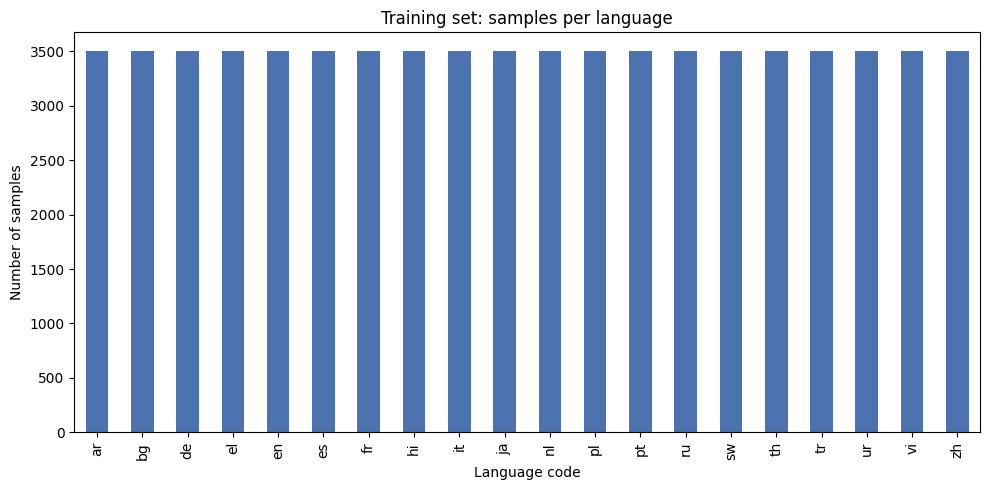


Number of distinct languages: 20
Min class count: 3500 | Max class count: 3500


In [4]:
label_counts = train_df["labels"].value_counts().sort_index()
print(label_counts)

fig, ax = plt.subplots(figsize=(10, 5))
label_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Training set: samples per language")
ax.set_xlabel("Language code")
ax.set_ylabel("Number of samples")
plt.tight_layout()
plt.show()

print(f"\nNumber of distinct languages: {train_df['labels'].nunique()}")
print(f"Min class count: {label_counts.min()} | Max class count: {label_counts.max()}")




### 2.3 Tokenization pipeline


In [21]:
PAD_IDX = 0
UNK_IDX = 1
MAX_VOCAB_SIZE = 40_000
MAX_LEN = 64

TOKEN_RE = re.compile(r"\w+|[^\w\s]", re.UNICODE)

def tokenize(text: str):
    r"""Lowercase + split into word / punctuation tokens (language-agnostic, \w
    matches Unicode letters so this works across scripts, e.g. Cyrillic, Arabic,
    CJK characters are each captured as individual tokens by \w)."""
    return TOKEN_RE.findall(text.lower())

def build_vocab(texts, max_vocab_size=MAX_VOCAB_SIZE):
    counter = Counter()
    for t in texts:
        counter.update(tokenize(t))

    most_common = counter.most_common(max_vocab_size)
    vocab = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
    for tok, _ in most_common:
        if tok not in vocab:
            vocab[tok] = len(vocab)
    return vocab


vocab = build_vocab(train_df["text"].tolist())
print(f"Vocabulary size (incl. special tokens): {len(vocab):,}")


Vocabulary size (incl. special tokens): 40,002


In [6]:
def encode(text: str, vocab: dict, max_len: int = MAX_LEN):
    tokens = tokenize(text)
    ids = [vocab.get(tok, UNK_IDX) for tok in tokens][:max_len]
    length = len(ids)
    if length < max_len:
        ids = ids + [PAD_IDX] * (max_len - length)
    return ids, length


# Sanity check
sample_text = train_df.iloc[0]["text"]
sample_ids, sample_len = encode(sample_text, vocab)
print("Sample text:", sample_text[:80])
print("Encoded (first 20 ids):", sample_ids[:20])
print("True token length (pre-padding):", sample_len)


Sample text: os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e e
Encoded (first 20 ids): [453, 1, 12, 8038, 129, 1, 3, 1, 3, 1, 3, 15787, 3, 15788, 3, 23625, 185, 1, 1, 124]
True token length (pre-padding): 30


### 2.4 Label encoding

In [7]:
label_encoder = LabelEncoder()
label_encoder.fit(train_df["labels"])
num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print("Classes:", list(label_encoder.classes_))


Number of classes: 20
Classes: ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


### 2.5 PyTorch `Dataset` and `DataLoader` construction

In [8]:
class LanguageIDDataset(Dataset):
    def __init__(self, texts, labels, vocab, label_encoder, max_len=MAX_LEN):
        self.texts = texts
        self.labels = label_encoder.transform(labels)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids, length = encode(self.texts[idx], self.vocab, self.max_len)
        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )


train_ds = LanguageIDDataset(train_df["text"].tolist(), train_df["labels"].tolist(), vocab, label_encoder)
val_ds = LanguageIDDataset(val_df["text"].tolist(), val_df["labels"].tolist(), vocab, label_encoder)
test_ds = LanguageIDDataset(test_df["text"].tolist(), test_df["labels"].tolist(), vocab, label_encoder)

BATCH_SIZE = 128

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Train batches: 547 | Val batches: 79 | Test batches: 79


## 3. Architecture Design


In [9]:
class BiLSTMLanguageClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_classes,
        embed_dim=128,
        hidden_dim=128,
        num_layers=1,
        dropout=0.3,
        pad_idx=PAD_IDX,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embed_dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)          # (B, L, E)
        embedded = self.embed_dropout(embedded)

        lengths_clamped = lengths.clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths_clamped, batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)

        # h_n: (num_layers * 2, B, hidden_dim) -> take the last layer's
        # forward and backward hidden states and concatenate them.
        h_forward = h_n[-2]
        h_backward = h_n[-1]
        final_hidden = torch.cat([h_forward, h_backward], dim=1)  # (B, hidden_dim*2)

        logits = self.classifier(final_hidden)
        return logits


model = BiLSTMLanguageClassifier(
    vocab_size=len(vocab),
    num_classes=num_classes,
    embed_dim=128,
    hidden_dim=128,
    num_layers=1,
    dropout=0.3,
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")


BiLSTMLanguageClassifier(
  (embedding): Embedding(40002, 128, padding_idx=0)
  (embed_dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=20, bias=True)
  )
)

Trainable parameters: 5,419,924


## 4. Model Training & Evaluation

### 4.1 Training / evaluation loop helpers


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for input_ids, lengths, labels in loader:
            input_ids, lengths, labels = input_ids.to(device), lengths.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


### 4.2 Train for multiple epochs, tracking loss and accuracy

In [11]:
NUM_EPOCHS = 8

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start
    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"{elapsed:.1f}s"
    )


Epoch 01/8 | train_loss=0.7357 train_acc=0.7780 | val_loss=0.2059 val_acc=0.9437 | 259.2s
Epoch 02/8 | train_loss=0.1874 train_acc=0.9429 | val_loss=0.1723 val_acc=0.9577 | 247.8s
Epoch 03/8 | train_loss=0.1211 train_acc=0.9626 | val_loss=0.1441 val_acc=0.9676 | 251.6s
Epoch 04/8 | train_loss=0.0920 train_acc=0.9716 | val_loss=0.1448 val_acc=0.9692 | 253.9s
Epoch 05/8 | train_loss=0.0717 train_acc=0.9773 | val_loss=0.1332 val_acc=0.9713 | 258.0s
Epoch 06/8 | train_loss=0.0557 train_acc=0.9822 | val_loss=0.1431 val_acc=0.9722 | 259.4s
Epoch 07/8 | train_loss=0.0481 train_acc=0.9848 | val_loss=0.1409 val_acc=0.9721 | 247.1s
Epoch 08/8 | train_loss=0.0412 train_acc=0.9864 | val_loss=0.1376 val_acc=0.9743 | 246.1s


### 4.3 Plot training curves

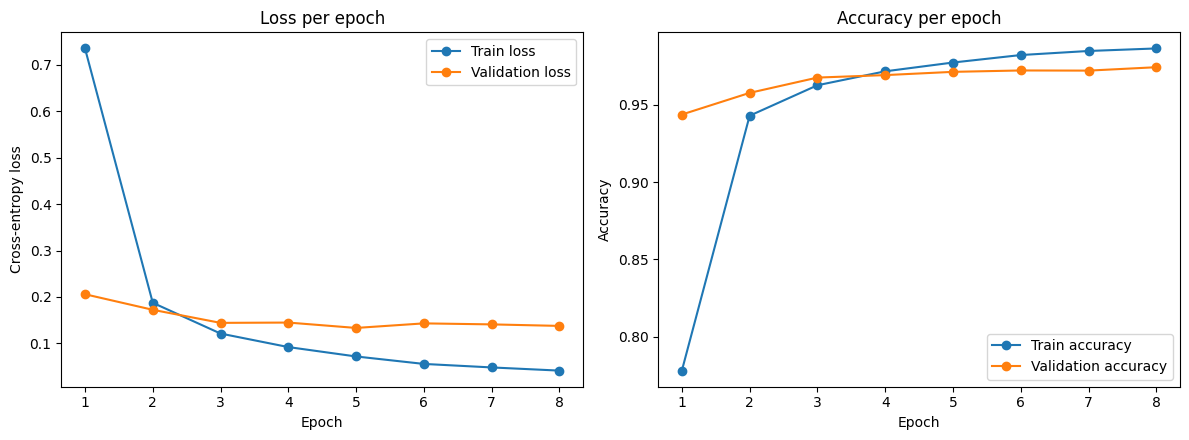

In [12]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_loss"], label="Train loss", marker="o")
axes[0].plot(epochs_range, history["val_loss"], label="Validation loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Loss per epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train accuracy", marker="o")
axes[1].plot(epochs_range, history["val_acc"], label="Validation accuracy", marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy per epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


### 4.4 Final evaluation on the held-out 10,000-sample test set

In [13]:
test_loss, test_acc = run_epoch(test_loader, model, criterion, optimizer=None)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")


Final test loss: 0.1347
Final test accuracy: 0.9725


In [14]:
# Detailed per-class report + confusion matrix
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for input_ids, lengths, labels in test_loader:
        input_ids, lengths = input_ids.to(device), lengths.to(device)
        logits = model(input_ids, lengths)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

target_names = label_encoder.classes_
print(classification_report(all_labels, all_preds, target_names=target_names, digits=3))


              precision    recall  f1-score   support

          ar      0.937     0.926     0.932       500
          bg      0.978     0.984     0.981       500
          de      0.996     0.994     0.995       500
          el      0.982     0.996     0.989       500
          en      0.998     0.990     0.994       500
          es      0.994     0.988     0.991       500
          fr      0.996     0.996     0.996       500
          hi      1.000     0.968     0.984       500
          it      0.974     0.970     0.972       500
          ja      0.946     0.972     0.959       500
          nl      0.990     0.980     0.985       500
          pl      0.888     0.968     0.926       500
          pt      0.953     0.970     0.961       500
          ru      0.978     0.974     0.976       500
          sw      0.973     0.948     0.960       500
          th      1.000     0.998     0.999       500
          tr      0.979     0.918     0.947       500
          ur      0.947    

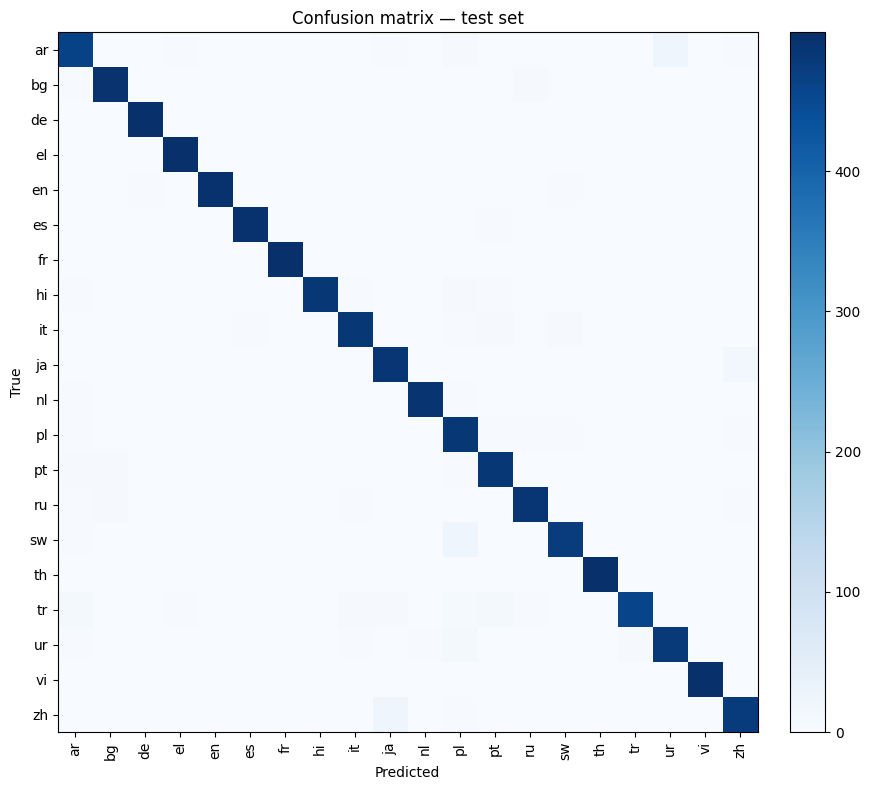

In [15]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(target_names, rotation=90)
ax.set_yticklabels(target_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix — test set")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 5. Custom Inference Pipeline



In [16]:
def predict_language(text: str, model, vocab, label_encoder, max_len=MAX_LEN, top_k=5):
    model.eval()
    ids, length = encode(text, vocab, max_len)

    input_ids = torch.tensor([ids], dtype=torch.long).to(device)
    lengths = torch.tensor([length], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_ids, lengths)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    ranked = sorted(
        zip(label_encoder.classes_, probs), key=lambda x: x[1], reverse=True
    )[:top_k]
    confidence_scores = {lang: float(p) for lang, p in ranked}

    return {
        "text": text,
        "predicted_language": pred_label,
        "confidence": float(probs[pred_idx]),
        "top_k_scores": confidence_scores,
    }


In [20]:
# Demo: a few short / ambiguous / multilingual example messages
demo_messages = [
    "Bonjour, pouvez-vous m'aider avec ma commande ?",
    "Hola, necesito ayuda con mi pedido por favor.",
    "Can you confirm the transaction reference number for my account?",
    "Guten Tag, ich habe eine Frage zu meiner Rechnung.",
    "Ok",
    "merci",
    "السلام عليكم",
]

for msg in demo_messages:
    result = predict_language(msg, model, vocab, label_encoder)
    print(f"Text: {result['text']!r}")
    print(f"  -> Predicted: {result['predicted_language']} (confidence: {result['confidence']:.3f})")
    print(f"  -> Top-{len(result['top_k_scores'])} scores: {result['top_k_scores']}")
    print()


Text: "Bonjour, pouvez-vous m'aider avec ma commande ?"
  -> Predicted: sw (confidence: 0.612)
  -> Top-5 scores: {'sw': 0.6122187972068787, 'fr': 0.2083805501461029, 'hi': 0.05168406292796135, 'el': 0.04236136004328728, 'ur': 0.013432824984192848}

Text: 'Hola, necesito ayuda con mi pedido por favor.'
  -> Predicted: es (confidence: 0.997)
  -> Top-5 scores: {'es': 0.9973284006118774, 'it': 0.0024262957740575075, 'pt': 0.0002144717436749488, 'nl': 1.6128544302773662e-05, 'fr': 1.0510930223972537e-05}

Text: 'Can you confirm the transaction reference number for my account?'
  -> Predicted: en (confidence: 0.994)
  -> Top-5 scores: {'en': 0.9943392872810364, 'sw': 0.00391489639878273, 'ur': 0.001627202145755291, 'pt': 5.562937440117821e-05, 'ar': 2.2885616999701597e-05}

Text: 'Guten Tag, ich habe eine Frage zu meiner Rechnung.'
  -> Predicted: de (confidence: 1.000)
  -> Top-5 scores: {'de': 0.9999887943267822, 'bg': 1.1204678230569698e-05, 'es': 1.1835586732900083e-08, 'fr': 1.9776005

## Results Summary

**Training:** The model converged quickly and stably over 8 epochs, with training accuracy rising from 77.8% to 98.6% and validation accuracy from 94.4% to 97.4%. A mild overfitting gap appeared after epoch ~4 (validation loss plateaued around 0.13–0.14 while training loss kept falling to 0.041), but validation accuracy kept improving throughout, so generalization was not meaningfully affected.

**Test set performance:** The final model achieved **97.3% accuracy** on the 10,000-sample held-out test set. Per-language F1 scores were strong and consistent across all 20 languages, ranging from 0.926 (Polish) to 0.999 (Thai). The weakest classes were Polish (0.888 precision) and Arabic (0.937 precision), while French, German, Thai, and Vietnamese were essentially perfect (F1 > 0.99).

**Inference behavior:** Live inference on formal, well-formed sentences (English, Spanish, German) was highly accurate with near-100% confidence. Performance degraded on very short inputs (e.g. "Ok", "merci"), which is expected given the minimal language signal available in 1–2 tokens. One informal, customer-service-style French sentence was misclassified with moderate confidence, likely reflecting a mismatch between the model's training data (product reviews, translated sentence pairs) and casual conversational phrasing — a useful limitation to flag given the task's emphasis on robustness to short, ambiguous text.